# Configuration

In [284]:
from pathlib import Path
import json
import pandas as pd
import re
import matplotlib.pyplot as plt

In [285]:
# ===== CONFIG =====
ROOT_DIR = Path("../data/processed/ner_predictions/")
MANIFEST_PATH = Path("../data/processed/manifests/ner_manifest_mapped_fixed.jsonl")
 
# Pick exactly which prediction files to include.
# Each entry is a path relative to ROOT_DIR, e.g. "llm_prompted_ner/mistral_7b_predictions.jsonl"
PREDICTION_FILES = [
    # Flair models (stored in bilstm_crf_ner folder but are Flair)
    "bilstm_crf_ner/flair_ner-english-large_predictions.jsonl",
    "bilstm_crf_ner/flair_ner-english-ontonotes_predictions.jsonl",
    "bilstm_crf_ner/flair_ner-english-ontonotes-large_predictions.jsonl",
    # BiLSTM-CRF models
    #"bilstm_crf_ner/ner_predictions.jsonl",
    #"bilstm_crf_ner/ner-fast_predictions.jsonl",
    #"bilstm_crf_ner/ner-large_predictions.jsonl",
    # Transformer models
    "transformer_ner/Gladiator_microsoft-deberta-v3-large_ner_conll2003_predictions_fixed.jsonl",
    "transformer_ner/dbmdz_bert-large-cased-finetuned-conll03-english_predictions.jsonl",
    "transformer_ner/dslim_bert-base-NER_predictions.jsonl",
    #"transformer_ner/elastic_distilbert-base-cased-finetuned-conll03-english_predictions.jsonl",
    "transformer_ner/Jean-Baptiste_roberta-large-ner-english_predictions.jsonl",
    # New NER models
    "gliner_treshold8.jsonl",
    "presidio.jsonl",
    "presidio_trf.jsonl",
]

CLEAN_NAMES = {
    # Flair models (all in bilstm_crf_ner/ folder)
    "flair_ner-english-large_predictions":                                  "Flair (english-large)",
    "flair_ner-english-ontonotes_predictions":                              "Flair (OntoNotes)",
    "flair_ner-english-ontonotes-large_predictions":                        "Flair (OntoNotes Large)",
    "ner_predictions":                                                      "Flair (ner)",
    "ner-fast_predictions":                                                 "Flair (ner-fast)",
    "ner-large_predictions":                                                "Flair (ner-large)",
    # Transformers
    "Gladiator_microsoft-deberta-v3-large_ner_conll2003_predictions_fixed": "DeBERTa (Large)",
    "dbmdz_bert-large-cased-finetuned-conll03-english_predictions":         "BERT (Large)",
    "dslim_bert-base-NER_predictions":                                      "BERT (Base)",
    "elastic_distilbert-base-cased-finetuned-conll03-english_predictions":  "DistilBERT",
    "Jean-Baptiste_roberta-large-ner-english_predictions":                  "RoBERTa (Large)",
    # New NER
    "gliner_treshold8":                                                     "GLiNER medium",
    "presidio":                                                             "Presidio + spaCy",
    "presidio_trf":                                                         "Presidio TRF + spaCy",
}

# Label normalisation — raw predicted label → standard label
# Covers: legacy LLM labels, GLiNER natural-language labels,
#         HydroX uppercase labels, Presidio entity types
LABEL_MAP = {
    # LLM / legacy lowercase
    "person":                  "PER",
    "location":                "LOC",
    "company":                 "ORG",
    "organization":            "ORG",
    "date":                    "DATE",
    "time":                    "TIME",
    "money":                   "MONEY",
    # GLiNER — uppercase with spaces (actual output format)
    "PERSON NAME":             "PER",
    "ORGANIZATION":            "ORG",
    "LOCATION":                "LOC",
    "PHYSICAL ADDRESS":        "LOC",
    "EMAIL ADDRESS":           "EMAIL",
    "PHONE NUMBER":            "PHONE",
    "DATE OF BIRTH":           "DOB",
    "SOCIAL SECURITY NUMBER":  "SSN",
    "IP ADDRESS":              "IP",
    "PASSPORT NUMBER":         "PASSPORT",
    # Presidio entity types
    "PERSON":                  "PER",
    "ORG":                     "ORG",
    "NRP":                     "ORG",
    "GPE":                     "LOC",
    "FAC":                     "LOC",
    "DATE_TIME":               "DATE",
    "URL":                     "URL",
}

# Only evaluate these labels (set to None to evaluate all)
PII_LABELS = {"PER", "LOC", "ORG"}
 
# ==================

In [286]:
# =========================
# HELPERS
# =========================
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows
 
def load_jsonl_df(path):
    return pd.DataFrame(load_jsonl(path))
 
def normalize_text(s):
    if pd.isna(s) or s is None:
        return None
    return re.sub(r"\s+", " ", str(s).lower().strip())
 
def load_selected_predictions(root_dir, prediction_files):
    """Load only the explicitly listed prediction files."""
    all_rows = []
    missing = []
    for rel_path in prediction_files:
        file = root_dir / rel_path
        if not file.exists():
            missing.append(rel_path)
            continue
        model_name = file.stem
        for row in load_jsonl(file):
            row["model_name"] = model_name
            row["source_file"] = rel_path
            all_rows.append(row)
 
    if missing:
        print(f"[warn] {len(missing)} file(s) not found:")
        for m in missing:
            print(f"  {m}")
 
    df = pd.DataFrame(all_rows)
    print(f"Loaded {len(df)} rows from {len(prediction_files) - len(missing)} file(s)")
    return df

# Data Loading

In [287]:
# =========================
# LOAD
# =========================
manifest_df = load_jsonl_df(MANIFEST_PATH)
pred_df = load_selected_predictions(ROOT_DIR, PREDICTION_FILES)

Loaded 470550 rows from 10 file(s)


# Preprocessing

In [288]:
# =========================
# EXPLODE GOLD
# =========================
def explode_manifest_entities(df):
    rows = []
    for _, row in df.iterrows():
        for ent in row.get("entities", []):
            rows.append({
                "segment_id":       row["segment_id"],
                "meeting_id":       row.get("meeting_id"),
                "speaker_id":       row.get("speaker_id"),
                "text":             row.get("text"),
                "entity_text":      ent.get("text"),
                "entity_text_norm": normalize_text(ent.get("text")),
                "start_char":       ent.get("start_char"),
                "end_char":         ent.get("end_char"),
                "raw_label":        ent.get("label"),
                "std_label":        ent.get("std_label"),
            })
    return pd.DataFrame(rows)

In [289]:
# =========================
# EXPLODE PREDICTIONS
# =========================
def explode_predictions(df, label_map):
    rows = []
    for _, row in df.iterrows():
        for ent in row.get("predicted_entities", []):
            raw_label = ent.get("label")
            mapped_label = label_map.get(raw_label, raw_label)
            rows.append({
                "model_name":       row["model_name"],
                "source_file":      row.get("source_file"),
                "segment_id":       row["segment_id"],
                "meeting_id":       row.get("meeting_id"),
                "speaker_id":       row.get("speaker_id"),
                "text":             row.get("text"),
                "entity_text":      ent.get("text"),
                "entity_text_norm": normalize_text(ent.get("text")),
                "start_char":       ent.get("start_char"),
                "end_char":         ent.get("end_char"),
                "raw_label":        raw_label,
                "std_label":        mapped_label,
                "score":            ent.get("score"),
                "latency_ms":       row.get("latency_ms"),
            })
    return pd.DataFrame(rows)

In [290]:
gold_entities_df = explode_manifest_entities(manifest_df)
pred_entities_df = explode_predictions(pred_df, LABEL_MAP)

In [291]:
# Sanity check — verify label mapping worked for new models
unmapped = pred_entities_df[
    ~pred_entities_df["std_label"].isin(set(LABEL_MAP.values()))
]["raw_label"].value_counts()
if not unmapped.empty:
    print("[warn] Unmapped labels (not in LABEL_MAP values) — may be filtered out:")
    print(unmapped.to_string())

[warn] Unmapped labels (not in LABEL_MAP values) — may be filtered out:
raw_label
CARDINAL       8663
MISC           6182
ORDINAL        1222
PERCENT         466
PRODUCT         405
QUANTITY        152
NORP             90
LANGUAGE         75
WORK_OF_ART      63
EVENT            11
LAW               1


In [292]:
# Issue 1 fix: compute latency from the utterance-level pred_df BEFORE exploding,
# so counts are not inflated by the number of entities per utterance.
#
# Outlier removal:
#   - WARMUP_DROP: skip the first N rows per model (warmup + cold-start effects)
#   - OUTLIER_PERCENTILE: clip the top X% to remove server contention spikes
WARMUP_DROP = 5          # rows to drop from the start of each model's predictions
OUTLIER_PERCENTILE = 98  # clip anything above this percentile
 
def trim_latencies(df, warmup_drop, outlier_pct):
    pieces = []
    for model_name, group in df.groupby("model_name"):
        g = group.iloc[warmup_drop:].copy()
        threshold = g["latency_ms"].quantile(outlier_pct / 100)
        pieces.append(g[g["latency_ms"] <= threshold])
    return pd.concat(pieces, ignore_index=True)
 
pred_df_latency = trim_latencies(pred_df, WARMUP_DROP, OUTLIER_PERCENTILE)
n_dropped = len(pred_df) - len(pred_df_latency)
print(f"Latency: dropped {n_dropped} rows ({n_dropped/len(pred_df)*100:.1f}%) — "
      f"{WARMUP_DROP} warmup + top {100-OUTLIER_PERCENTILE}% outliers per model")
 
latency_df = (
    pred_df_latency.groupby("model_name")["latency_ms"]
    .agg(latency_mean="mean", latency_p50="median",
         latency_p95=lambda x: x.quantile(0.95))
    .reset_index()
    .round(2)
)
print("\nLatency summary (ms):")
display(latency_df)

Latency: dropped 9398 rows (2.0%) — 5 warmup + top 2% outliers per model

Latency summary (ms):


,model_name,latency_mean,latency_p50,latency_p95
0,Gladiator_microsoft-deberta-v3-large_ner_conll...,3.86,3.86,5.34
1,Jean-Baptiste_roberta-large-ner-english_predic...,2.80,2.86,3.91
2,dbmdz_bert-large-cased-finetuned-conll03-engli...,3.34,3.34,4.63
3,dslim_bert-base-NER_predictions,1.66,1.61,2.46
4,flair_ner-english-large_predictions,25.81,26.86,37.92
5,flair_ner-english-ontonotes-large_predictions,25.00,25.62,37.51
6,flair_ner-english-ontonotes_predictions,18.65,10.37,66.65
7,gliner_treshold8,24.82,20.75,39.88
8,presidio,8.69,7.93,14.15
9,presidio_trf,17.76,16.80,24.13


In [293]:
# =========================
# DEDUPLICATE
# =========================
 
# Gold: straightforward dedup on span + label
gold_entities_df = gold_entities_df.drop_duplicates(
    subset=["segment_id", "start_char", "end_char", "std_label", "entity_text_norm"]
).copy()

In [294]:
# Issue 3 fix: for predictions, resolve overlapping spans per model+segment
# by keeping only the highest-scoring span when two predictions overlap.
# This prevents overlapping predictions (e.g. "John Smith" and "John" for the
# same gold entity) from both counting as separate FPs or inflating TP counts.
def resolve_overlapping_spans(df):
    """
    Within each (model_name, segment_id) group, greedily keep the
    highest-scoring span, dropping any lower-scoring span that overlaps with it.
    Falls back to start_char order if scores are equal.
    """
    resolved = []
    for (model_name, segment_id), group in df.groupby(["model_name", "segment_id"]):
        spans = (
            group
            .sort_values("score", ascending=False)
            .reset_index(drop=True)
        )
        kept = []
        for _, span in spans.iterrows():
            overlap = any(
                not (span["end_char"] <= k["start_char"] or span["start_char"] >= k["end_char"])
                for k in kept
            )
            if not overlap:
                kept.append(span)
        resolved.append(pd.DataFrame(kept))
    return pd.concat(resolved, ignore_index=True) if resolved else df.iloc[0:0]
 
pred_entities_df = resolve_overlapping_spans(pred_entities_df)

In [295]:
# =========================
# LABEL FILTER
# =========================
if PII_LABELS:
    gold_eval_df = gold_entities_df[gold_entities_df["std_label"].isin(PII_LABELS)].copy()
    pred_eval_df = pred_entities_df[pred_entities_df["std_label"].isin(PII_LABELS)].copy()
else:
    gold_eval_df = gold_entities_df.copy()
    pred_eval_df = pred_entities_df.copy()
 
print(f"Gold entities for eval: {gold_eval_df.shape}")
print(f"Pred entities for eval: {pred_eval_df.shape}")

Gold entities for eval: (1263, 10)
Pred entities for eval: (18553, 14)


# Evaluation

In [296]:
# =========================
# METRIC HELPERS
# =========================
def _tp_fp_fn(pred_keys, gold_keys, on):
    tp = len(pred_keys.merge(gold_keys, on=on, how="inner"))
    fp = len(pred_keys) - tp
    fn = len(gold_keys) - tp
    return tp, fp, fn
 
def _prf(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return round(precision, 4), round(recall, 4), round(f1, 4)
 
def compute_metrics(gold_df, pred_df, match_cols, label=""):
    gold_keys = gold_df[match_cols].drop_duplicates()
    results = []
    for model_name, model_pred in pred_df.groupby("model_name"):
        pred_keys = model_pred[match_cols].drop_duplicates()
        tp, fp, fn = _tp_fp_fn(pred_keys, gold_keys, on=match_cols)
        p, r, f1 = _prf(tp, fp, fn)
        results.append({"model_name": model_name, "tp": tp, "fp": fp, "fn": fn,
                         "precision": p, "recall": r, "f1": f1})
    df = (pd.DataFrame(results)
            .sort_values("f1", ascending=False)
            .reset_index(drop=True))
    if label:
        print(f"\n{label}:")
        display(df)
    return df
 
 
def compute_metrics_occurrence(gold_df, pred_df, label=""):
    """
    Issue 5 fix: count every occurrence of an entity text in a segment,
    not just whether it appears at least once. Uses span-based matching
    (start_char + end_char must be in match_cols) so each mention is
    counted independently.
    """
    # Anchor on segment_id + start_char + end_char to count occurrences
    occurrence_cols = ["segment_id", "start_char", "end_char", "std_label"]
    gold_keys = gold_df[occurrence_cols].copy()
    results = []
    for model_name, model_pred in pred_df.groupby("model_name"):
        pred_keys = model_pred[occurrence_cols].copy()
        tp, fp, fn = _tp_fp_fn(pred_keys, gold_keys, on=occurrence_cols)
        p, r, f1 = _prf(tp, fp, fn)
        results.append({"model_name": model_name, "tp": tp, "fp": fp, "fn": fn,
                         "precision": p, "recall": r, "f1": f1})
    df = (pd.DataFrame(results)
            .sort_values("f1", ascending=False)
            .reset_index(drop=True))
    if label:
        print(f"\n{label}:")
        display(df)
    return df

def display_clean(df, label):
    out = df.copy()
    out["model"] = out["model_name"].map(CLEAN_NAMES).fillna(out["model_name"])
    out = out[["model", "tp", "fp", "fn", "precision", "recall", "f1"]].sort_values("f1", ascending=False).reset_index(drop=True)
    print(f"\n{label}:")
    display(out)
    return out

## Metrics

In [297]:
# =========================
# 1) STRICT TYPED — exact span + label
# =========================
strict_df = compute_metrics(
    gold_eval_df, pred_eval_df,
    match_cols=["segment_id", "start_char", "end_char", "std_label"],
)
strict_df = display_clean(strict_df, "Strict typed (exact span + label)")

# =========================
# 1b) STRICT OCCURRENCE-AWARE — counts every mention, not just unique text
# =========================
strict_occurrence_df = compute_metrics_occurrence(gold_eval_df, pred_eval_df)
strict_occurrence_df = display_clean(strict_occurrence_df, "Strict occurrence-aware (every mention counted)")

# =========================
# 2) RELAXED TEXT + LABEL — normalised text + label
# =========================
relaxed_df = compute_metrics(
    gold_eval_df, pred_eval_df,
    match_cols=["segment_id", "entity_text_norm", "std_label"],
)
relaxed_df = display_clean(relaxed_df, "Relaxed text + label")

# =========================
# 3) TEXT ONLY — normalised text, ignore label
# =========================
text_only_df = compute_metrics(
    gold_eval_df, pred_eval_df,
    match_cols=["segment_id", "entity_text_norm"],
)
text_only_df = display_clean(text_only_df, "Text only (no label check)")


Strict typed (exact span + label):


,model,tp,fp,fn,precision,recall,f1
0,DeBERTa (Large),706,546,557,0.5639,0.5590,0.5614
1,Flair (OntoNotes Large),677,676,586,0.5004,0.5360,0.5176
2,Flair (english-large),692,739,571,0.4836,0.5479,0.5137
3,Flair (OntoNotes),649,776,614,0.4554,0.5139,0.4829
4,BERT (Large),690,1031,573,0.4009,0.5463,0.4625
5,BERT (Base),592,919,671,0.3918,0.4687,0.4268
6,RoBERTa (Large),729,1454,534,0.3339,0.5772,0.4231
7,Presidio + spaCy,610,1287,653,0.3216,0.4830,0.3861
8,Presidio TRF + spaCy,650,2311,613,0.2195,0.5146,0.3078
9,GLiNER medium,549,2270,714,0.1947,0.4347,0.2690



Strict occurrence-aware (every mention counted):


,model,tp,fp,fn,precision,recall,f1
0,DeBERTa (Large),706,546,557,0.5639,0.5590,0.5614
1,Flair (OntoNotes Large),677,676,586,0.5004,0.5360,0.5176
2,Flair (english-large),692,739,571,0.4836,0.5479,0.5137
3,Flair (OntoNotes),649,776,614,0.4554,0.5139,0.4829
4,BERT (Large),690,1031,573,0.4009,0.5463,0.4625
5,BERT (Base),592,919,671,0.3918,0.4687,0.4268
6,RoBERTa (Large),729,1454,534,0.3339,0.5772,0.4231
7,Presidio + spaCy,610,1287,653,0.3216,0.4830,0.3861
8,Presidio TRF + spaCy,650,2311,613,0.2195,0.5146,0.3078
9,GLiNER medium,549,2270,714,0.1947,0.4347,0.2690



Relaxed text + label:


,model,tp,fp,fn,precision,recall,f1
0,DeBERTa (Large),708,501,555,0.5856,0.5606,0.5728
1,Flair (OntoNotes Large),680,636,583,0.5167,0.5384,0.5273
2,Flair (english-large),695,692,568,0.5011,0.5503,0.5245
3,Flair (OntoNotes),652,744,611,0.4670,0.5162,0.4904
4,BERT (Large),691,979,572,0.4138,0.5471,0.4712
5,BERT (Base),595,863,668,0.4081,0.4711,0.4373
6,RoBERTa (Large),731,1393,532,0.3442,0.5788,0.4317
7,GLiNER medium,550,914,713,0.3757,0.4355,0.4034
8,Presidio + spaCy,613,1229,650,0.3328,0.4854,0.3948
9,Presidio TRF + spaCy,652,2264,611,0.2236,0.5162,0.3120



Text only (no label check):


,model,tp,fp,fn,precision,recall,f1
0,DeBERTa (Large),722,485,541,0.5982,0.5717,0.5846
1,Flair (english-large),711,676,552,0.5126,0.5629,0.5366
2,Flair (OntoNotes Large),687,629,576,0.5220,0.5439,0.5328
3,Flair (OntoNotes),670,725,593,0.4803,0.5305,0.5041
4,BERT (Large),711,959,552,0.4257,0.5629,0.4848
5,BERT (Base),615,841,648,0.4224,0.4869,0.4524
6,RoBERTa (Large),757,1366,506,0.3566,0.5994,0.4471
7,GLiNER medium,561,903,702,0.3832,0.4442,0.4114
8,Presidio + spaCy,625,1217,638,0.3393,0.4949,0.4026
9,Presidio TRF + spaCy,660,2256,603,0.2263,0.5226,0.3159


In [298]:
# =========================
# COMBINED SUMMARY TABLE
# =========================
latency_df["model"] = latency_df["model_name"].map(CLEAN_NAMES).fillna(latency_df["model_name"])

summary_df = (
    relaxed_df[["model", "precision", "recall", "f1"]]
    .merge(latency_df[["model", "latency_mean", "latency_p95"]], on="model")
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)
print("\nCombined summary (Relaxed text + label, cleaned gold + latency):")
display(summary_df)


Combined summary (Relaxed text + label, cleaned gold + latency):


,model,precision,recall,f1,latency_mean,latency_p95
0,DeBERTa (Large),0.5856,0.5606,0.5728,3.86,5.34
1,Flair (OntoNotes Large),0.5167,0.5384,0.5273,25.00,37.51
2,Flair (english-large),0.5011,0.5503,0.5245,25.81,37.92
3,Flair (OntoNotes),0.4670,0.5162,0.4904,18.65,66.65
4,BERT (Large),0.4138,0.5471,0.4712,3.34,4.63
5,BERT (Base),0.4081,0.4711,0.4373,1.66,2.46
6,RoBERTa (Large),0.3442,0.5788,0.4317,2.80,3.91
7,GLiNER medium,0.3757,0.4355,0.4034,24.82,39.88
8,Presidio + spaCy,0.3328,0.4854,0.3948,8.69,14.15
9,Presidio TRF + spaCy,0.2236,0.5162,0.3120,17.76,24.13


## Plots

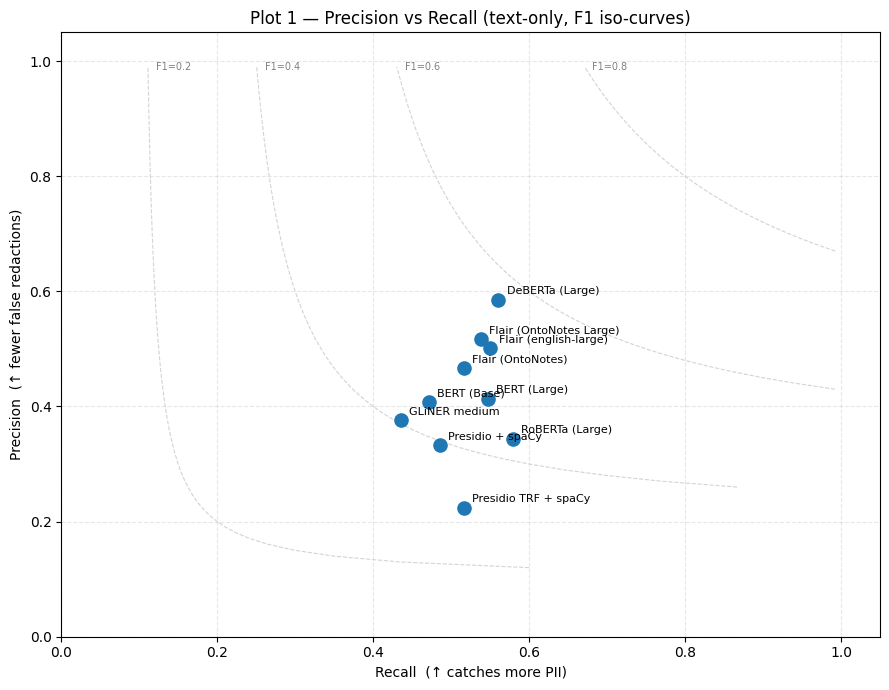

In [299]:
# =========================
# PLOT 1 — Precision vs Recall scatter with F1 iso-curves
# Shows the tradeoff between over-redacting (low precision)
# and missing PII (low recall) — both have different consequences.
# =========================
fig, ax = plt.subplots(figsize=(9, 7))
 
# Draw F1 iso-curves
p_vals = pd.Series([i / 100 for i in range(1, 100)])
for f1_target in [0.2, 0.4, 0.6, 0.8]:
    r_vals = (f1_target * p_vals) / (2 * p_vals - f1_target)
    mask = (r_vals >= 0) & (r_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], color="lightgray", linewidth=0.8, linestyle="--")
    ax.text(r_vals[mask].iloc[-1] + 0.01, p_vals[mask].iloc[-1],
            f"F1={f1_target}", fontsize=7, color="gray", va="center")
 
ax.scatter(summary_df["recall"], summary_df["precision"], s=90, zorder=3)
for _, row in summary_df.iterrows():
    ax.annotate(row["model"], xy=(row["recall"], row["precision"]),
                xytext=(6, 4), textcoords="offset points", fontsize=8)
 
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Recall  (↑ catches more PII)")
ax.set_ylabel("Precision  (↑ fewer false redactions)")
ax.set_title("Plot 1 — Precision vs Recall (text-only, F1 iso-curves)")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\pmoreira\AppData\Local\Temp\ipykernel_46800\357293855.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grouped, labels=model_order, patch_artist=True,


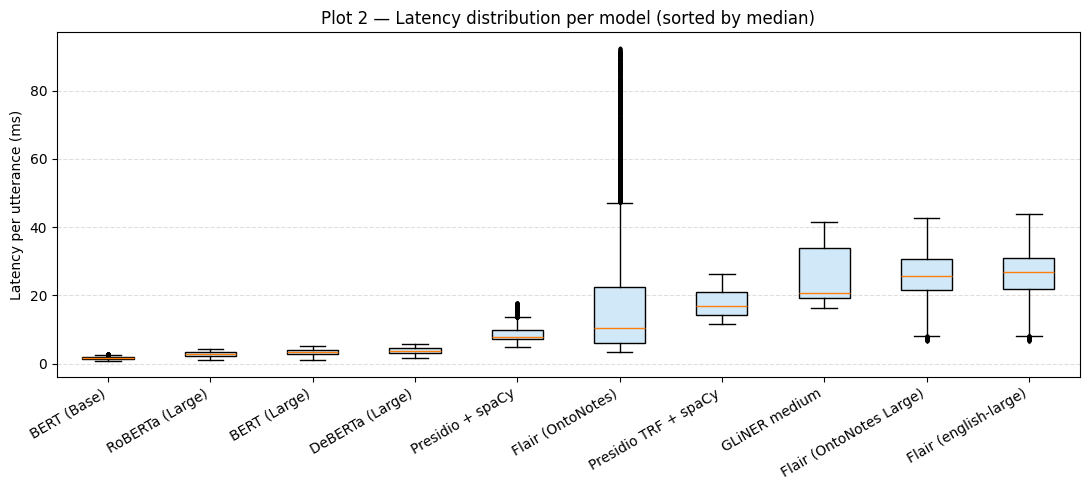

In [300]:
# =========================
# PLOT 2 — Latency distribution box plot per model
# Mean hides tail behaviour — for real-time use, p95 spikes matter.
# =========================
 
# Build per-utterance latency from pred_df_latency (trimmed, pre-explode)
latency_records = pred_df_latency[["model_name", "latency_ms"]].copy()
latency_records["model"] = latency_records["model_name"].map(CLEAN_NAMES).fillna(latency_records["model_name"])
 
model_order = (
    latency_records.groupby("model")["latency_ms"]
    .median()
    .sort_values()
    .index.tolist()
)
 
grouped = [
    latency_records[latency_records["model"] == m]["latency_ms"].dropna().values
    for m in model_order
]
 
fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(grouped, labels=model_order, patch_artist=True,
                showfliers=True, flierprops=dict(marker=".", markersize=3, alpha=0.4))
for patch in bp["boxes"]:
    patch.set_facecolor("#d0e8f7")
 
ax.set_ylabel("Latency per utterance (ms)")
ax.set_title("Plot 2 — Latency distribution per model (sorted by median)")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

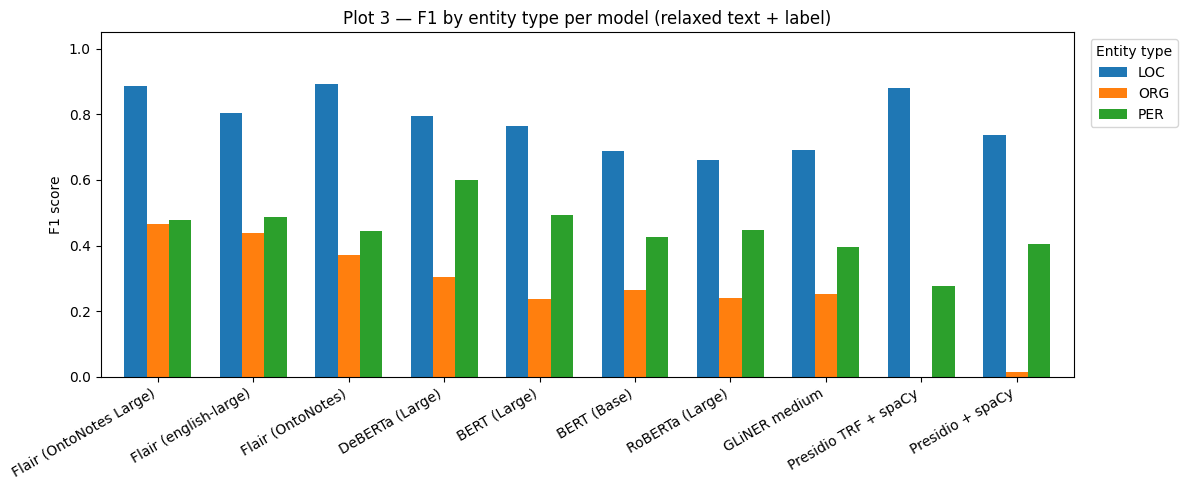

In [301]:
# =========================
# PLOT 3 — F1 by entity type per model (grouped bar)
# Overall F1 masks per-type behaviour. A model may be strong on
# PERSON but miss ORG entirely, which matters for your use case.
# =========================
def compute_per_type_f1(gold_df, pred_df):
    rows = []
    gold_keys = gold_df[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()
    for model_name, model_pred in pred_df.groupby("model_name"):
        pred_keys = model_pred[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()
        for label in sorted(gold_df["std_label"].unique()):
            gk = gold_keys[gold_keys["std_label"] == label]
            pk = pred_keys[pred_keys["std_label"] == label]
            tp, fp, fn = _tp_fp_fn(pk, gk, on=["segment_id", "entity_text_norm", "std_label"])
            _, _, f1 = _prf(tp, fp, fn)
            rows.append({"model_name": model_name, "label": label, "f1": f1})
    return pd.DataFrame(rows)
 
per_type_df = compute_per_type_f1(gold_eval_df, pred_eval_df)
per_type_df["model"] = per_type_df["model_name"].map(CLEAN_NAMES).fillna(per_type_df["model_name"])
 
pivot = per_type_df.pivot(index="model", columns="label", values="f1").fillna(0)
# Order rows by mean F1 descending
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
 
ax = pivot.plot(kind="bar", figsize=(12, 5), width=0.7)
ax.set_xlabel("")
ax.set_ylabel("F1 score")
ax.set_title("Plot 3 — F1 by entity type per model (relaxed text + label)")
ax.set_ylim(0, 1.05)
ax.legend(title="Entity type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

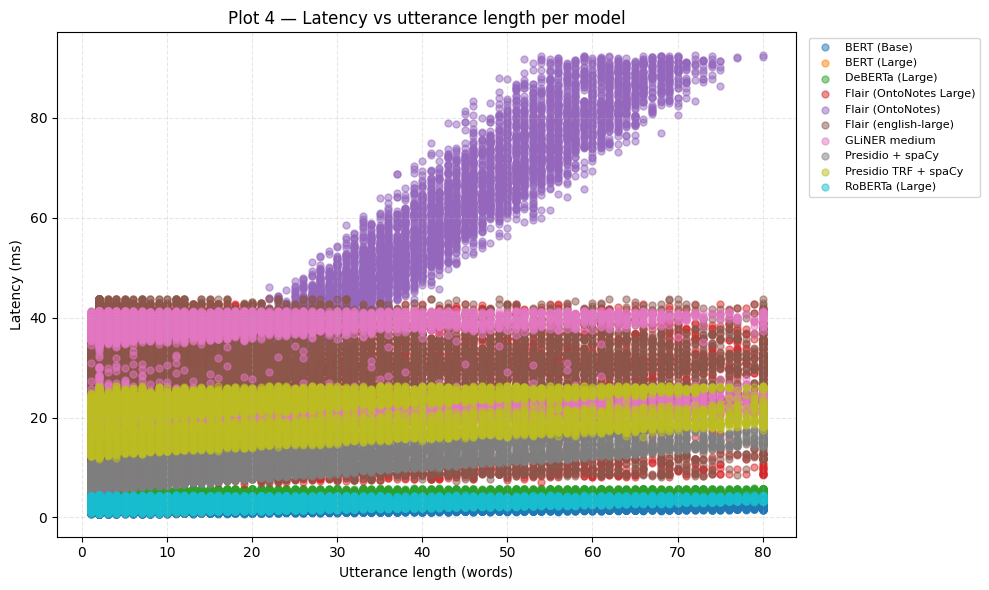

In [302]:
# =========================
# PLOT 4 — Latency vs utterance length scatter
# Checks whether any model degrades on longer segments.
# Particularly important for GLiNER which scales with span count.
# =========================
 
# Attach word count to pred_df
pred_df_plot = pred_df_latency.copy()
pred_df_plot["word_count"] = pred_df_plot["text"].fillna("").apply(lambda t: len(t.split()))
pred_df_plot["model"] = pred_df_plot["model_name"].map(CLEAN_NAMES).fillna(pred_df_plot["model_name"])
 
models = pred_df_plot["model"].unique()
colors = plt.cm.tab10.colors
 
fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(sorted(models)):
    subset = pred_df_plot[pred_df_plot["model"] == model]
    ax.scatter(subset["word_count"], subset["latency_ms"],
               label=model, alpha=0.5, s=25, color=colors[i % len(colors)])
 
ax.set_xlabel("Utterance length (words)")
ax.set_ylabel("Latency (ms)")
ax.set_title("Plot 4 — Latency vs utterance length per model")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()
 

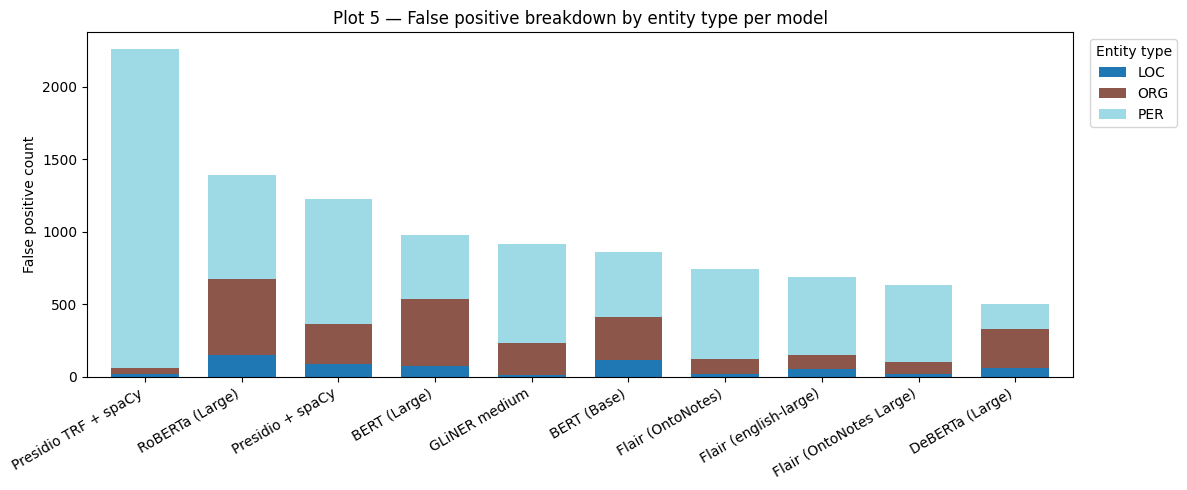

In [303]:
# =========================
# PLOT 5 — False positive breakdown by label (stacked bar)
# Shows whether FPs are concentrated in one fixable label
# or spread across types (a deeper model quality issue).
# =========================
gold_keys_all = gold_eval_df[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()
 
fp_rows = []
for model_name, model_pred in pred_eval_df.groupby("model_name"):
    pred_keys = model_pred[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()
    # FPs = predictions that do NOT match any gold key
    merged = pred_keys.merge(gold_keys_all,
                             on=["segment_id", "entity_text_norm", "std_label"],
                             how="left", indicator=True)
    fp_preds = merged[merged["_merge"] == "left_only"]
    for label, count in fp_preds["std_label"].value_counts().items():
        fp_rows.append({"model_name": model_name, "label": label, "fp_count": count})
 
fp_df = pd.DataFrame(fp_rows)
if not fp_df.empty:
    fp_df["model"] = fp_df["model_name"].map(CLEAN_NAMES).fillna(fp_df["model_name"])
    fp_pivot = fp_df.pivot_table(index="model", columns="label", values="fp_count", fill_value=0)
    # Order by total FPs descending
    fp_pivot = fp_pivot.loc[fp_pivot.sum(axis=1).sort_values(ascending=False).index]
 
    ax = fp_pivot.plot(kind="bar", stacked=True, figsize=(12, 5), width=0.7, colormap="tab20")
    ax.set_xlabel("")
    ax.set_ylabel("False positive count")
    ax.set_title("Plot 5 — False positive breakdown by entity type per model")
    ax.legend(title="Entity type", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No false positives found — skipping Plot 5.")

# Gold Entities

## Entities Analysis

In [304]:
# Find gold entities that every model missed
gold_keys = gold_eval_df[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()
all_pred_keys = pred_eval_df[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()

# FNs = gold entities not found by any model
universal_fn = gold_keys.merge(
    all_pred_keys,
    on=["segment_id", "entity_text_norm", "std_label"],
    how="left",
    indicator=True
).query('_merge == "left_only"').drop(columns="_merge")

print(f"Gold entities missed by ALL models: {len(universal_fn)} / {len(gold_keys)}")
print(f"That's {len(universal_fn)/len(gold_keys)*100:.1f}% of gold entities\n")

# Attach the original text for context
fn_with_context = universal_fn.merge(
    manifest_df[["segment_id", "text", "speaker_id", "meeting_id"]],
    on="segment_id",
    how="left"
)

# Sample 30 for manual inspection
sample = fn_with_context.sample(min(30, len(fn_with_context)), random_state=42)
display(sample[["meeting_id", "speaker_id", "segment_id", "std_label", "entity_text_norm", "text"]].reset_index(drop=True))

Gold entities missed by ALL models: 480 / 1263
That's 38.0% of gold entities



,meeting_id,speaker_id,segment_id,std_label,entity_text_norm,text
0,ES2007a,A,ES2007a_A_0228420_0231280_0021,PER,industrial designer,"Uh Miss Industrial Designer , would you like t..."
1,IS1009d,A,IS1009d_A_1394880_1413280_0113,PER,marketing expert,I'm sorry to interrupt then but I just uh reco...
2,IS1009b,B,IS1009b_B_1210370_1230380_0030,PER,user interface designer,I can make it full ? Yes yes yes . Okay . As u...
3,IS1003a,D,IS1003a_D_0405290_0419530_0022,PER,industrial designer,"Yeah , I'm just go I'm trying to give you some..."
4,IS1009c,A,IS1009c_A_0210260_0228560_0019,PER,interface designer,Francino who is our um interface designer um u...
5,ES2013b,D,ES2013b_D_0344180_0364400_0014,ORG,real reaction,make some decisions about what what keys or or...
6,IS1003a,B,IS1003a_B_0317930_0321300_0007,PER,user interface design,No I'm user interf I'm user interface design .
7,IS1008b,B,IS1008b_B_0350220_0370390_0014,PER,industrial designer,And um it would uh y you'd you could throw it ...
8,ES2007a,A,ES2007a_A_1138310_1145820_0110,PER,industrial designer,"Industrial Designer , you are the one , you kn..."
9,TS3005a,A,TS3005a_A_1163250_1183410_0068,PER,marketing expert,"Ah well that's good , five minutes and uh the ..."


## Entities Cleaning

In [305]:
# =========================
# GOLD CLEANING
#
# Manual FN inspection identified five categories removed/fixed before evaluation:
#
# 1. ROLE TITLES — AMI annotates job roles (e.g. "marketing expert") as PER,
#    but standard NER models correctly do not tag roles as person names.
#    Accounts for ~53% of original FNs. Removed via keyword matching.
#
# 2. SPELLED ACRONYMS — AMI transcribes letters with underscores (e.g. "i_d_",
#    "b_b_c_"). Undetectable by any standard model. Removed via regex.
#
# 3. ANNOTATION ERRORS — a small set of clearly mislabelled or non-entity
#    spans identified during manual inspection (e.g. "of" as LOC,
#    "veronica" as ORG). Removed via exact match.
#
# 4. POSSESSIVE NORMALISATION — suffixes ('s, 've) stripped from entity_text_norm
#    in both gold and predictions so "pedro's" matches "pedro" in relaxed eval.
#
# 5. POSSESSIVE SPAN FIX — gold spans include the possessive suffix in end_char
#    (e.g. gold has "Craig's" with end_char covering the 's) while models
#    correctly predict just "Craig". end_char trimmed by 2 where applicable
#    so strict span matching counts these as TPs instead of mismatches.
#
# =========================

ROLE_KEYWORDS = [
    "designer", "manager", "expert", "engineer",
    "developer", "director", "analyst", "architect",
    "marketing", "industrial", "coach", "researcher",
    "user interface", "market research", "marketing team",
    "marketing person", "project leader", "project supervisor",
    "usability", "interface guy", "interface um", "interface",
]

ANNOTATION_ERRORS = {
    "innovative so",   # transcription fragment, not an entity
    "good decision",   # not an entity
    "of",              # preposition labelled as LOC
    "veronica",        # person name labelled as ORG
    "philip",          # person name labelled as ORG
}

def is_role_title(s):
    return any(kw in str(s) for kw in ROLE_KEYWORDS)

def is_spelled_acronym(s):
    return bool(re.match(r"^([a-z]_){2,}$", str(s)))

def strip_possessive(s):
    if pd.isna(s):
        return s
    return re.sub(r"('s|'ve|')$", "", str(s)).strip()

def fix_possessive_spans(df):
    """
    Trim end_char by 2 where entity_text ends with 's so strict span
    boundaries match model predictions (name only, no possessive suffix).
    """
    df = df.copy()
    mask = df["entity_text"].str.endswith("'s", na=False)
    df.loc[mask, "end_char"] = df.loc[mask, "end_char"] - 2
    df.loc[mask, "entity_text"] = df.loc[mask, "entity_text"].str[:-2]
    df.loc[mask, "entity_text_norm"] = df.loc[mask, "entity_text_norm"].apply(strip_possessive)
    return df

# Apply to gold
gold_eval_clean = gold_eval_df.copy()
gold_eval_clean = gold_eval_clean[~gold_eval_clean["entity_text_norm"].apply(is_role_title)]
gold_eval_clean = gold_eval_clean[~gold_eval_clean["entity_text_norm"].apply(is_spelled_acronym)]
gold_eval_clean = gold_eval_clean[~gold_eval_clean["entity_text_norm"].isin(ANNOTATION_ERRORS)]
gold_eval_clean = fix_possessive_spans(gold_eval_clean)
gold_eval_clean["entity_text_norm"] = gold_eval_clean["entity_text_norm"].apply(strip_possessive)
gold_eval_clean = gold_eval_clean.drop_duplicates(
    subset=["segment_id", "entity_text_norm", "std_label"]
).copy()

# Apply possessive stripping to predictions too so matching is consistent
pred_eval_clean = pred_eval_df.copy()
pred_eval_clean["entity_text_norm"] = pred_eval_clean["entity_text_norm"].apply(strip_possessive)

n_role       = gold_eval_df["entity_text_norm"].apply(is_role_title).sum()
n_acronym    = gold_eval_df["entity_text_norm"].apply(is_spelled_acronym).sum()
n_errors     = gold_eval_df["entity_text_norm"].isin(ANNOTATION_ERRORS).sum()
n_possessive = gold_eval_df["entity_text"].str.endswith("'s", na=False).sum()
print(f"Original gold entities   : {len(gold_eval_df)}")
print(f"  Removed role titles    : {n_role}")
print(f"  Removed acronyms       : {n_acronym}")
print(f"  Removed annot. errors  : {n_errors}")
print(f"  Possessive spans fixed : {n_possessive}")
print(f"After cleaning           : {len(gold_eval_clean)}")

Original gold entities   : 1263
  Removed role titles    : 374
  Removed acronyms       : 59
  Removed annot. errors  : 2
  Possessive spans fixed : 48
After cleaning           : 824


# Model Fixes

In [306]:
ENTITY_LENGTH_FILTER = False  # set to True to filter out very short entities that are hard to detect and often noise

MIN_ENTITY_LENGTH = {
    "PER": 3,   # at least 3 chars — filters "ed", "jo" etc
    "LOC": 3,
    "ORG": 4,   # slightly stricter for ORG given low precision
}

if (ENTITY_LENGTH_FILTER):
    pred_eval_clean = pred_eval_clean[
        pred_eval_clean.apply(
            lambda r: len(str(r["entity_text_norm"])) >= MIN_ENTITY_LENGTH.get(r["std_label"], 3),
            axis=1
        )
    ].copy()

In [307]:
STOPWRDS_FILTER = False  # set to True to filter out common words that are not useful as entities and often noise

STOPWORDS = {
    "uh", "um", "so", "oh", "kay", "'kay", "okay", "right",
    "yeah", "yes", "no", "well", "like", "just", "really",
    "actually", "basically", "anyway", "alright", "mm", "hmm",
    "nice", "good", "sure", "great", "fine", "true", "said",
}

if (STOPWRDS_FILTER):
    pred_eval_clean = pred_eval_clean[
        ~pred_eval_clean["entity_text_norm"].isin(STOPWORDS)
    ].copy()

# Evaluation With Cleaning

## Metrics with Cleaning

In [308]:
# =========================
# CLEANED METRICS
# =========================

strict_clean_df = compute_metrics(
    gold_eval_clean, pred_eval_clean,
    match_cols=["segment_id", "start_char", "end_char", "std_label"],
)
strict_clean_df = display_clean(strict_clean_df, "Strict typed — cleaned gold")

relaxed_clean_df = compute_metrics(
    gold_eval_clean, pred_eval_clean,
    match_cols=["segment_id", "entity_text_norm", "std_label"],
)
relaxed_clean_df = display_clean(relaxed_clean_df, "Relaxed text + label — cleaned gold")

text_only_clean_df = compute_metrics(
    gold_eval_clean, pred_eval_clean,
    match_cols=["segment_id", "entity_text_norm"],
)
text_only_clean_df = display_clean(text_only_clean_df, "Text only — cleaned gold")


Strict typed — cleaned gold:


,model,tp,fp,fn,precision,recall,f1
0,DeBERTa (Large),738,514,86,0.5895,0.8956,0.7110
1,Flair (OntoNotes Large),702,651,122,0.5188,0.8519,0.6449
2,Flair (english-large),725,706,99,0.5066,0.8799,0.6430
3,Flair (OntoNotes),682,743,142,0.4786,0.8277,0.6065
4,BERT (Large),722,999,102,0.4195,0.8762,0.5674
5,BERT (Base),621,890,203,0.4110,0.7536,0.5319
6,RoBERTa (Large),752,1431,72,0.3445,0.9126,0.5002
7,Presidio + spaCy,636,1261,188,0.3353,0.7718,0.4675
8,Presidio TRF + spaCy,678,2283,146,0.2290,0.8228,0.3583
9,GLiNER medium,581,2238,243,0.2061,0.7051,0.3190



Relaxed text + label — cleaned gold:


,model,tp,fp,fn,precision,recall,f1
0,DeBERTa (Large),744,465,80,0.6154,0.9029,0.7319
1,Flair (OntoNotes Large),709,607,115,0.5388,0.8604,0.6626
2,Flair (english-large),731,656,93,0.5270,0.8871,0.6612
3,Flair (OntoNotes),687,709,137,0.4921,0.8337,0.6189
4,BERT (Large),726,944,98,0.4347,0.8811,0.5822
5,BERT (Base),627,831,197,0.4300,0.7609,0.5495
6,RoBERTa (Large),759,1365,65,0.3573,0.9211,0.5149
7,GLiNER medium,584,880,240,0.3989,0.7087,0.5105
8,Presidio + spaCy,640,1202,184,0.3474,0.7767,0.4801
9,Presidio TRF + spaCy,681,2235,143,0.2335,0.8265,0.3642



Text only — cleaned gold:


,model,tp,fp,fn,precision,recall,f1
0,DeBERTa (Large),754,453,70,0.6247,0.9150,0.7425
1,Flair (english-large),745,642,79,0.5371,0.9041,0.6739
2,Flair (OntoNotes Large),715,601,109,0.5433,0.8677,0.6682
3,Flair (OntoNotes),694,701,130,0.4975,0.8422,0.6255
4,BERT (Large),741,929,83,0.4437,0.8993,0.5942
5,BERT (Base),638,818,186,0.4382,0.7743,0.5596
6,RoBERTa (Large),771,1352,53,0.3632,0.9357,0.5232
7,GLiNER medium,589,875,235,0.4023,0.7148,0.5149
8,Presidio + spaCy,651,1191,173,0.3534,0.7900,0.4884
9,Presidio TRF + spaCy,687,2229,137,0.2356,0.8337,0.3674


In [309]:
# =========================
# COMBINED SUMMARY TABLE
# =========================
latency_df["model"] = latency_df["model_name"].map(CLEAN_NAMES).fillna(latency_df["model_name"])

summary_df = (
    relaxed_clean_df[["model", "precision", "recall", "f1"]]
    .merge(latency_df[["model", "latency_mean", "latency_p95"]], on="model")
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)
print("\nCombined summary (Relaxed text + label, cleaned gold + latency):")
display(summary_df)


Combined summary (Relaxed text + label, cleaned gold + latency):


,model,precision,recall,f1,latency_mean,latency_p95
0,DeBERTa (Large),0.6154,0.9029,0.7319,3.86,5.34
1,Flair (OntoNotes Large),0.5388,0.8604,0.6626,25.00,37.51
2,Flair (english-large),0.5270,0.8871,0.6612,25.81,37.92
3,Flair (OntoNotes),0.4921,0.8337,0.6189,18.65,66.65
4,BERT (Large),0.4347,0.8811,0.5822,3.34,4.63
5,BERT (Base),0.4300,0.7609,0.5495,1.66,2.46
6,RoBERTa (Large),0.3573,0.9211,0.5149,2.80,3.91
7,GLiNER medium,0.3989,0.7087,0.5105,24.82,39.88
8,Presidio + spaCy,0.3474,0.7767,0.4801,8.69,14.15
9,Presidio TRF + spaCy,0.2335,0.8265,0.3642,17.76,24.13


## Plots with Cleaning

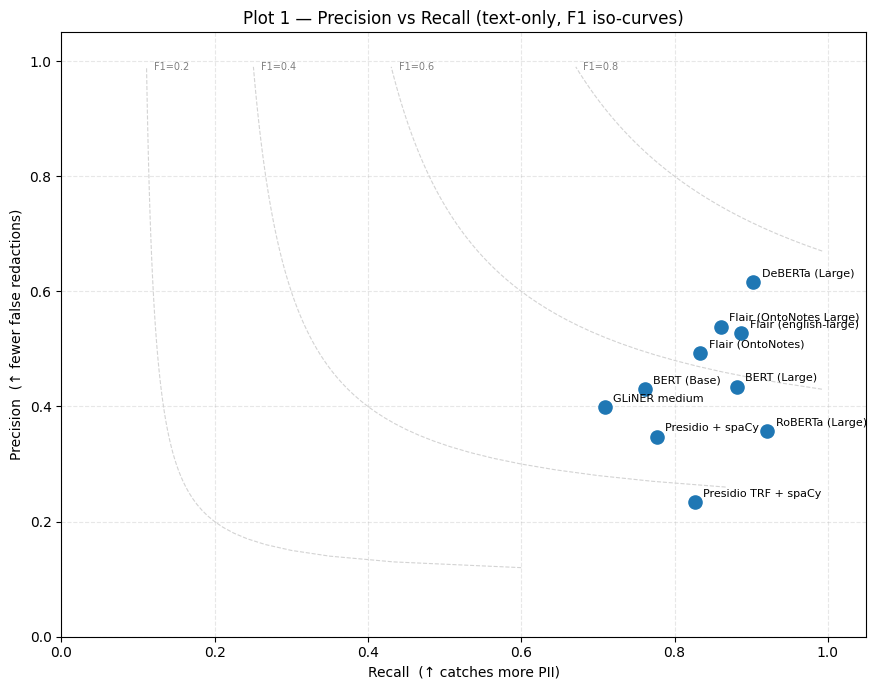

In [310]:
# =========================
# PLOT 1 — Precision vs Recall scatter with F1 iso-curves
# Shows the tradeoff between over-redacting (low precision)
# and missing PII (low recall) — both have different consequences.
# =========================
fig, ax = plt.subplots(figsize=(9, 7))
 
# Draw F1 iso-curves
p_vals = pd.Series([i / 100 for i in range(1, 100)])
for f1_target in [0.2, 0.4, 0.6, 0.8]:
    r_vals = (f1_target * p_vals) / (2 * p_vals - f1_target)
    mask = (r_vals >= 0) & (r_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], color="lightgray", linewidth=0.8, linestyle="--")
    ax.text(r_vals[mask].iloc[-1] + 0.01, p_vals[mask].iloc[-1],
            f"F1={f1_target}", fontsize=7, color="gray", va="center")
 
ax.scatter(summary_df["recall"], summary_df["precision"], s=90, zorder=3)
for _, row in summary_df.iterrows():
    ax.annotate(row["model"], xy=(row["recall"], row["precision"]),
                xytext=(6, 4), textcoords="offset points", fontsize=8)
 
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Recall  (↑ catches more PII)")
ax.set_ylabel("Precision  (↑ fewer false redactions)")
ax.set_title("Plot 1 — Precision vs Recall (text-only, F1 iso-curves)")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

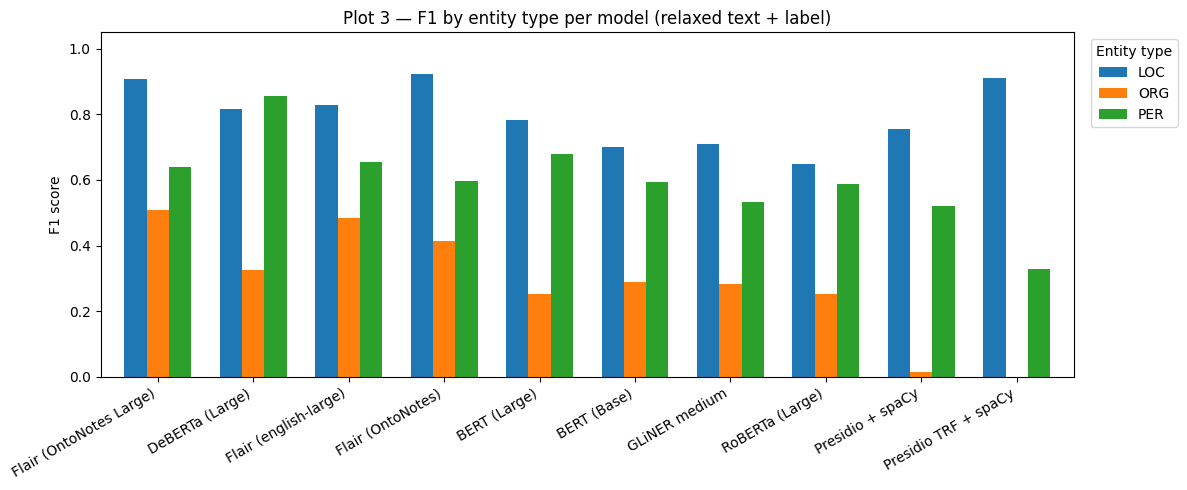

In [311]:
# =========================
# PLOT 3 — F1 by entity type per model (grouped bar)
# Overall F1 masks per-type behaviour. A model may be strong on
# PERSON but miss ORG entirely, which matters for your use case.
# =========================
def compute_per_type_f1(gold_df, pred_df):
    rows = []
    gold_keys = gold_df[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()
    for model_name, model_pred in pred_df.groupby("model_name"):
        pred_keys = model_pred[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()
        for label in sorted(gold_df["std_label"].unique()):
            gk = gold_keys[gold_keys["std_label"] == label]
            pk = pred_keys[pred_keys["std_label"] == label]
            tp, fp, fn = _tp_fp_fn(pk, gk, on=["segment_id", "entity_text_norm", "std_label"])
            _, _, f1 = _prf(tp, fp, fn)
            rows.append({"model_name": model_name, "label": label, "f1": f1})
    return pd.DataFrame(rows)
 
per_type_df = compute_per_type_f1(gold_eval_clean, pred_eval_clean)
per_type_df["model"] = per_type_df["model_name"].map(CLEAN_NAMES).fillna(per_type_df["model_name"])
 
pivot = per_type_df.pivot(index="model", columns="label", values="f1").fillna(0)
# Order rows by mean F1 descending
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
 
ax = pivot.plot(kind="bar", figsize=(12, 5), width=0.7)
ax.set_xlabel("")
ax.set_ylabel("F1 score")
ax.set_title("Plot 3 — F1 by entity type per model (relaxed text + label)")
ax.set_ylim(0, 1.05)
ax.legend(title="Entity type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

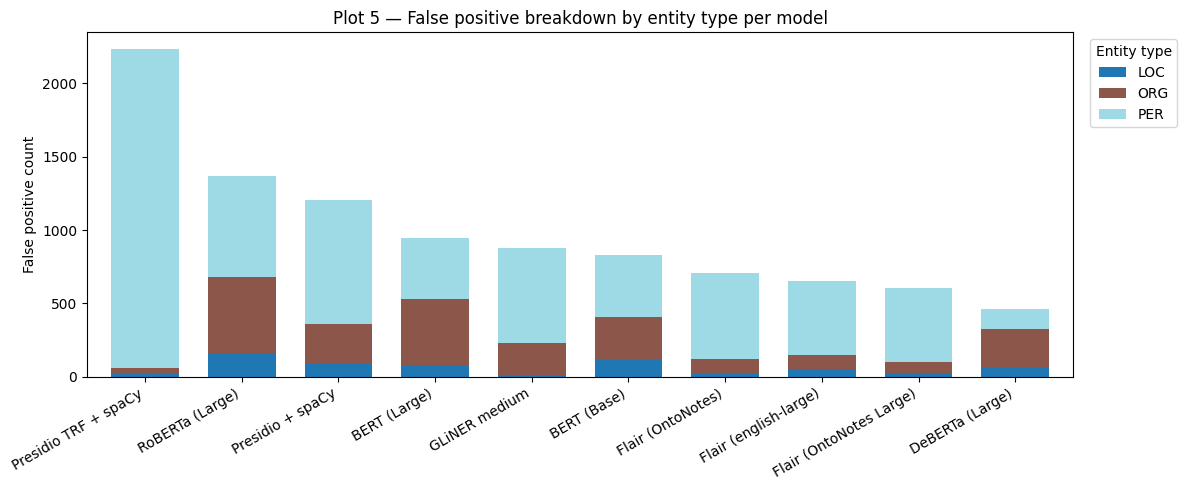

In [312]:
# =========================
# PLOT 5 — False positive breakdown by label (stacked bar)
# Shows whether FPs are concentrated in one fixable label
# or spread across types (a deeper model quality issue).
# =========================
gold_keys_all = gold_eval_clean[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()
 
fp_rows = []
for model_name, model_pred in pred_eval_clean.groupby("model_name"):
    pred_keys = model_pred[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()
    # FPs = predictions that do NOT match any gold key
    merged = pred_keys.merge(gold_keys_all,
                             on=["segment_id", "entity_text_norm", "std_label"],
                             how="left", indicator=True)
    fp_preds = merged[merged["_merge"] == "left_only"]
    for label, count in fp_preds["std_label"].value_counts().items():
        fp_rows.append({"model_name": model_name, "label": label, "fp_count": count})
 
fp_df = pd.DataFrame(fp_rows)
if not fp_df.empty:
    fp_df["model"] = fp_df["model_name"].map(CLEAN_NAMES).fillna(fp_df["model_name"])
    fp_pivot = fp_df.pivot_table(index="model", columns="label", values="fp_count", fill_value=0)
    # Order by total FPs descending
    fp_pivot = fp_pivot.loc[fp_pivot.sum(axis=1).sort_values(ascending=False).index]
 
    ax = fp_pivot.plot(kind="bar", stacked=True, figsize=(12, 5), width=0.7, colormap="tab20")
    ax.set_xlabel("")
    ax.set_ylabel("False positive count")
    ax.set_title("Plot 5 — False positive breakdown by entity type per model")
    ax.legend(title="Entity type", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No false positives found — skipping Plot 5.")

# Gold Entities after Cleaning

In [313]:
# Find gold entities missed by ALL models after cleaning
gold_keys_clean = gold_eval_clean[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()
all_pred_keys_clean = pred_eval_clean[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()

universal_fn_clean = gold_keys_clean.merge(
    all_pred_keys_clean,
    on=["segment_id", "entity_text_norm", "std_label"],
    how="left",
    indicator=True
).query('_merge == "left_only"').drop(columns="_merge")

# Attach context
fn_clean_context = universal_fn_clean.merge(
    manifest_df[["segment_id", "text", "speaker_id", "meeting_id"]],
    on="segment_id",
    how="left"
)

print(f"Total FNs after cleaning: {len(fn_clean_context)}")
print(f"\nBy entity type:")
print(fn_clean_context["std_label"].value_counts())

print(f"\nMost missed entity texts:")
print(fn_clean_context["entity_text_norm"].value_counts().head(20))

print(f"\nSample:")
display(
    fn_clean_context.sample(min(30, len(fn_clean_context)), random_state=42)
    [["meeting_id", "speaker_id", "segment_id", "std_label", "entity_text_norm", "text"]]
    .reset_index(drop=True)
)

Total FNs after cleaning: 20

By entity type:
std_label
ORG    13
PER     7
Name: count, dtype: int64

Most missed entity texts:
entity_text_norm
real reaction       12
kate                 1
cat                  1
maarika              1
rose                 1
mael                 1
epinions dot com     1
mark                 1
jurgen               1
Name: count, dtype: int64

Sample:


,meeting_id,speaker_id,segment_id,std_label,entity_text_norm,text
0,ES2002d,B,ES2002d_B_2286350_2290240_0229,ORG,real reaction,"Ah well , maybe from now on real reaction shou..."
1,IS1004b,B,IS1004b_B_0795540_0816060_0040,ORG,epinions dot com,Great . Okay so um while uh researching this t...
2,IS1003b,C,IS1003b_C_1363150_1365430_0103,ORG,real reaction,of the uh of real reaction
3,ES2003a,B,ES2003a_B_0002130_0013180_0000,ORG,real reaction,"Okay , well I think we're ready to begin . Rig..."
4,ES2008b,B,ES2008b_B_2200400_2202750_0120,PER,rose,"Yeah , that's what I have as well , R Rose So ."
5,ES2006b,A,ES2006b_A_1508020_1528070_0071,PER,cat,I think one of the very interesting things tha...
6,ES2015b,A,ES2015b_A_1677550_1680630_0071,ORG,real reaction,The little R_ R_ yellow thing ? Okay . Real Re...
7,ES2003b,B,ES2003b_B_2079980_2088060_0106,ORG,real reaction,"In fact we might like to put a slogan on , and..."
8,IS1006b,A,IS1006b_A_1960490_1975180_0107,PER,mark,uh of course the U_I_D_ Mark will be uh focuse...
9,IS1003b,C,IS1003b_C_1491230_1510230_0119,ORG,real reaction,Yeah . It has to be a fashion and really be uh...


# Model Complementarity Analysis

In [314]:
# =========================
# PAIRWISE MODEL COMPLEMENTARITY ANALYSIS
# =========================

models = pred_eval_clean["model_name"].unique()
gold_keys = gold_eval_clean[["segment_id", "entity_text_norm", "std_label"]].drop_duplicates()

# For each model, get the set of gold entities it correctly detects (TPs)
model_tps = {}
for model_name in models:
    pred_keys = (   
        pred_eval_clean[pred_eval_clean["model_name"] == model_name]
        [["segment_id", "entity_text_norm", "std_label"]]
        .drop_duplicates()
    )
    tp_keys = pred_keys.merge(gold_keys, on=["segment_id", "entity_text_norm", "std_label"], how="inner")
    model_tps[model_name] = set(zip(tp_keys["segment_id"], tp_keys["entity_text_norm"], tp_keys["std_label"]))

total_gold = len(gold_keys)

# Pairwise analysis
rows = []
for i, m1 in enumerate(models):
    for m2 in models:
        if m1 >= m2:
            continue
        union = model_tps[m1] | model_tps[m2]
        intersection = model_tps[m1] & model_tps[m2]
        only_m1 = model_tps[m1] - model_tps[m2]
        only_m2 = model_tps[m2] - model_tps[m1]

        combined_recall = len(union) / total_gold
        overlap_rate = len(intersection) / len(model_tps[m1] | model_tps[m2]) if union else 0

        rows.append({
            "model_1": CLEAN_NAMES.get(m1, m1),
            "model_2": CLEAN_NAMES.get(m2, m2),
            "recall_m1": round(len(model_tps[m1]) / total_gold, 4),
            "recall_m2": round(len(model_tps[m2]) / total_gold, 4),
            "combined_recall": round(combined_recall, 4),
            "recall_gain": round(combined_recall - max(len(model_tps[m1]), len(model_tps[m2])) / total_gold, 4),
            "overlap_rate": round(overlap_rate, 4),
            "only_m1": len(only_m1),
            "only_m2": len(only_m2),
            "shared_tps": len(intersection),
        })

pairs_df = pd.DataFrame(rows).sort_values("combined_recall", ascending=False).reset_index(drop=True)
display(pairs_df)

,model_1,model_2,recall_m1,recall_m2,combined_recall,recall_gain,overlap_rate,only_m1,only_m2,shared_tps
0,RoBERTa (Large),Flair (OntoNotes Large),0.9211,0.8604,0.9539,0.0328,0.8677,77,27,682
1,RoBERTa (Large),Presidio TRF + spaCy,0.9211,0.8265,0.9539,0.0328,0.8321,105,27,654
2,RoBERTa (Large),Flair (OntoNotes),0.9211,0.8337,0.9515,0.0303,0.8444,97,25,662
3,DeBERTa (Large),Flair (OntoNotes Large),0.9029,0.8604,0.9478,0.0449,0.8604,72,37,672
4,RoBERTa (Large),Presidio + spaCy,0.9211,0.7767,0.9466,0.0255,0.7936,140,21,619
5,BERT (Large),Flair (OntoNotes Large),0.8811,0.8604,0.9442,0.0631,0.8445,69,52,657
6,DeBERTa (Large),RoBERTa (Large),0.9029,0.9211,0.9417,0.0206,0.9369,17,32,727
7,BERT (Large),Flair (OntoNotes),0.8811,0.8337,0.9393,0.0583,0.8256,87,48,639
8,RoBERTa (Large),GLiNER medium,0.9211,0.7087,0.9393,0.0182,0.7351,190,15,569
9,DeBERTa (Large),Flair (OntoNotes),0.9029,0.8337,0.9393,0.0364,0.8488,87,30,657


# Misc

In [315]:
TYPE_ROUTING = {
    "PER": "Gladiator_microsoft-deberta-v3-large_ner_conll2003_predictions_fixed",
    "LOC": "flair_ner-english-ontonotes_predictions",
    "ORG": "flair_ner-english-ontonotes-large_predictions",  # or Flair english-large
}

def build_routed_ensemble(pred_eval_clean, routing):
    pieces = []
    for label, model_name in routing.items():
        subset = pred_eval_clean[
            (pred_eval_clean["model_name"] == model_name) &
            (pred_eval_clean["std_label"] == label)
        ].copy()
        subset["model_name"] = "routed_ensemble"
        pieces.append(subset)   
    return pd.concat(pieces, ignore_index=True)

ensemble_preds = build_routed_ensemble(pred_eval_clean, TYPE_ROUTING)

ensemble_df = compute_metrics(
    gold_eval_clean, ensemble_preds,
    match_cols=["segment_id", "entity_text_norm", "std_label"],
)
display_clean(ensemble_df, "Type-routed ensemble")


Type-routed ensemble:


,model,tp,fp,fn,precision,recall,f1
0,routed_ensemble,732,234,92,0.7578,0.8883,0.8179


,model,tp,fp,fn,precision,recall,f1
0,routed_ensemble,732,234,92,0.7578,0.8883,0.8179


In [316]:
def build_routed_ensemble_threshold(pred_eval_clean, routing, thresholds):
    pieces = []
    for label, model_name in routing.items():
        thresh = thresholds.get(label, 0.0)
        subset = pred_eval_clean[
            (pred_eval_clean["model_name"] == model_name) &
            (pred_eval_clean["std_label"] == label) &
            (pred_eval_clean["score"] >= thresh)
        ].copy()
        subset["model_name"] = "routed_ensemble"
        pieces.append(subset)
    return pd.concat(pieces, ignore_index=True)

# Sweep thresholds per type
for per_thresh in [0.5, 0.6, 0.7, 0.8, 0.9]:
    for loc_thresh in [0.5, 0.6, 0.7, 0.8]:
        for org_thresh in [0.3, 0.4, 0.5, 0.6]:
            thresholds = {"PER": per_thresh, "LOC": loc_thresh, "ORG": org_thresh}
            ens = build_routed_ensemble_threshold(pred_eval_clean, TYPE_ROUTING, thresholds)
            df = compute_metrics(gold_eval_clean, ens,
                                 match_cols=["segment_id", "entity_text_norm", "std_label"])
            p, r, f1 = df.iloc[0][["precision", "recall", "f1"]]
            if f1 > 0.82:
                print(f"thresh={thresholds}  P={p:.3f}  R={r:.3f}  F1={f1:.3f}")

thresh={'PER': 0.7, 'LOC': 0.8, 'ORG': 0.3}  P=0.787  R=0.857  F1=0.821
thresh={'PER': 0.7, 'LOC': 0.8, 'ORG': 0.4}  P=0.787  R=0.857  F1=0.821
thresh={'PER': 0.7, 'LOC': 0.8, 'ORG': 0.5}  P=0.787  R=0.857  F1=0.821
thresh={'PER': 0.7, 'LOC': 0.8, 'ORG': 0.6}  P=0.787  R=0.857  F1=0.821
thresh={'PER': 0.8, 'LOC': 0.5, 'ORG': 0.3}  P=0.793  R=0.854  F1=0.822
thresh={'PER': 0.8, 'LOC': 0.5, 'ORG': 0.4}  P=0.793  R=0.854  F1=0.822
thresh={'PER': 0.8, 'LOC': 0.5, 'ORG': 0.5}  P=0.793  R=0.854  F1=0.822
thresh={'PER': 0.8, 'LOC': 0.5, 'ORG': 0.6}  P=0.793  R=0.854  F1=0.822
thresh={'PER': 0.8, 'LOC': 0.6, 'ORG': 0.3}  P=0.793  R=0.853  F1=0.822
thresh={'PER': 0.8, 'LOC': 0.6, 'ORG': 0.4}  P=0.793  R=0.853  F1=0.822
thresh={'PER': 0.8, 'LOC': 0.6, 'ORG': 0.5}  P=0.793  R=0.853  F1=0.822
thresh={'PER': 0.8, 'LOC': 0.6, 'ORG': 0.6}  P=0.793  R=0.853  F1=0.822
thresh={'PER': 0.8, 'LOC': 0.7, 'ORG': 0.3}  P=0.797  R=0.851  F1=0.823
thresh={'PER': 0.8, 'LOC': 0.7, 'ORG': 0.4}  P=0.797  R=0.851  F